In [49]:
import math
import numpy as np
import pandas as pd
import scipy
import statsmodels.api as sm
import matplotlib.pyplot as plt

### Real Data Analysis

In [50]:
def normality_tests(arr):
    '''Set of tests for normality distribution'''

    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    sm.qqplot(arr, line='s', ax=ax)
    plt.show()

    print('Skew of data set %14.3f' % scipy.stats.skew(arr))
    print('Skew test p-value %14.3f' % scipy.stats.skewtest(arr)[1])
    print('Kurt of data set %14.3f' % scipy.stats.kurtosis(arr))
    print('Kurt test p-value %14.3f' % scipy.stats.kurtosistest(arr)[1])
    print('Norm test p-value %14.3f' % scipy.stats.normaltest(arr)[1])

In [51]:
raw = pd.read_csv('~/quant_finance/python_for_finance/tr_eikon_eod_data.csv', index_col=0, parse_dates=True).dropna()
data = raw[['SPY', 'GLD', 'AAPL.O', 'MSFT.O']]
data.head()

,SPY,GLD,AAPL.O,MSFT.O
Date,,,,
2010-01-04,113.33,109.80,30.572827,30.950
2010-01-05,113.63,109.70,30.625684,30.960
2010-01-06,113.71,111.51,30.138541,30.770
2010-01-07,114.19,110.82,30.082827,30.452
2010-01-08,114.57,111.37,30.282827,30.660


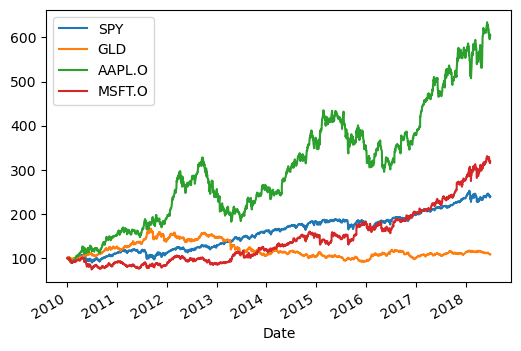

In [52]:
# Plot the time series, setting starting point @ 100
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
(data / data.iloc[0] * 100).plot(ax=ax)
plt.show()

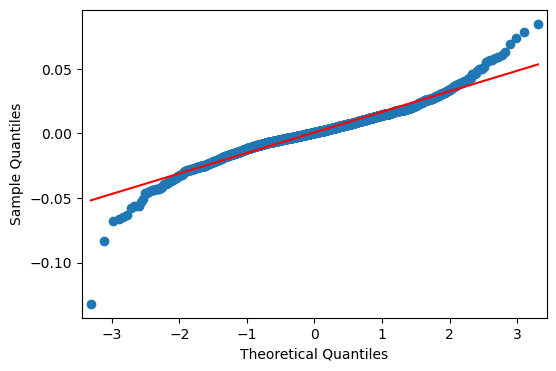

Skew of data set         -0.235
Skew test p-value          0.000
Kurt of data set          4.790
Kurt test p-value          0.000
Norm test p-value          0.000


In [53]:
# Daily log-returns
log_returns = np.log(data / data.shift(1))

normality_tests(log_returns['AAPL.O'].dropna())

array([[<Axes: title={'center': 'SPY'}>, <Axes: title={'center': 'GLD'}>],
       [<Axes: title={'center': 'AAPL.O'}>,
        <Axes: title={'center': 'MSFT.O'}>]], dtype=object)

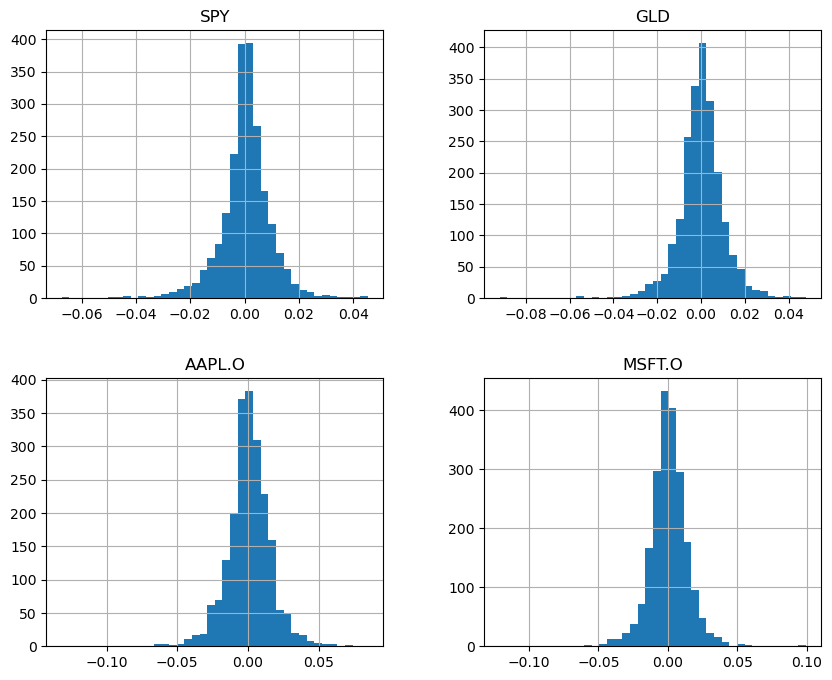

In [54]:
log_returns.hist(bins=40, figsize=(10, 8))

### Minimum Variance Portfolio
Assumptions: 
- Investors can only hold long positions (weights > 0, no shorting allowed)
- 100% of an inverstor's wealth is split among all positions

Essential ingredients:
- Expected portfolio return: $\mu_p = E\left[ \sum_j w_j k_j \right] = \sum_j w_j E\left[ k_j \right] = \sum_j w_j \mu_j = w^T \mu$
- Expected portfolio variance: $\sigma_{p}^2 = Var \left( \sum_j w_j k_j \right) = Cov \left( \sum_j w_j k_j, \sum_j w_j k_j \right) = \sum_{i,k = 1}^m w_i w_j \Sigma_{ij} = w^T \Sigma w$

In [55]:
nAssets = log_returns.shape[1]

# Generate random proportions for each asset with constraint of sum = 1
weights = np.random.uniform(0, 1, size=nAssets)
weights /= np.sum(weights)

# Consider the daily log-returns, we need to find the annualized log-returns
nTradingDays = 252
mean_log_returns = log_returns.mean(axis=0) * nTradingDays
cov_log_returns = log_returns.cov() * nTradingDays

# Expected portfolio return
mu = np.dot(mean_log_returns.to_numpy(), weights)

# Expected portfolio variance
var = weights.T @ cov_log_returns @ weights

# Expected portfolio volatility (standard deviation)
vol = np.sqrt(var)

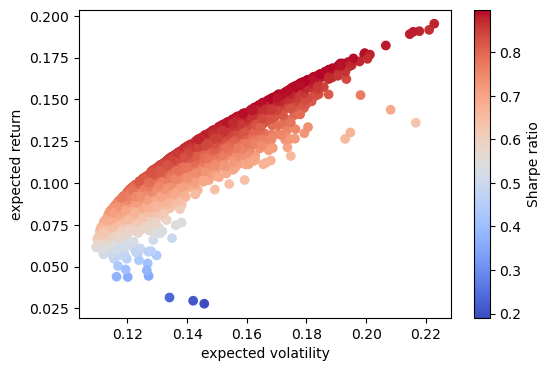

In [56]:
# Monte Carlo simulation of various weights (Markowitz bullet)
def port_return(w):
    return nTradingDays * log_returns.mean(axis=0) @ w

def port_volatility(w):
    return np.sqrt(w.T @ (log_returns.cov() * nTradingDays) @ w)

prets = []
pvols = []
for p in range (2500):
    weights = np.random.random(nAssets)
    weights /= np.sum(weights)
    prets.append(port_return(weights))
    pvols.append(port_volatility(weights))
prets = np.array(prets)
pvols = np.array(pvols)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
sc = ax.scatter(
    pvols,
    prets,
    c=prets / pvols,
    marker='o',
    cmap='coolwarm'
)
ax.set_xlabel('expected volatility')
ax.set_ylabel('expected return')
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Sharpe ratio')
plt.show()

It is clear that not all weight distributions perform well when measured in terms of mean and volatility

For example, for a fixed risk level (expected volatility) of 15%, there are multiple portfolios that all show different returns. As an investor, one is generally interested in the maximum return given a fixed risk level or the minimum risk given a fixed return expectation. This set of portfolios then makes up the so-called efficient frontier

### Portfolio Optimization 
#### 1. Sharpe Ratio maximization

Maximization of Sharpe ratio
Optimal weights: [0.2545411  0.04228124 0.51191355 0.19126411]
Portfolio return with optimal weights: 0.1614313671065792
Portfolio volatility with optimal weights: 0.17983427827611914
Sharpe ratio with optimal weights: 0.8976673894101327


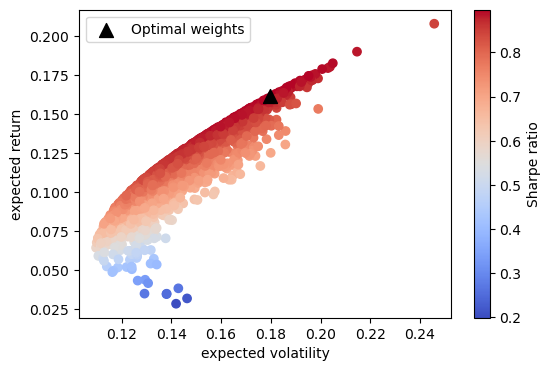

In [62]:
def neg_sharpe_ratio(w):
    '''Negative Sharpie ratio to be minimized'''
    port_return = w @ log_returns.mean(axis=0) * 252
    port_volatility = np.sqrt(w.T @ (log_returns.cov() * 252) @ w)
    sharpe_ratio = port_return / port_volatility # assuming no risk-free rate
    return -sharpe_ratio

constraints = ({'type': 'eq', # equality of constraint
                'fun': lambda x: np.sum(x) - 1}, # weights sum to 1
            )

results = scipy.optimize.minimize(
    fun=neg_sharpe_ratio, 
    x0=np.array([1 / nAssets] * nAssets),    # starting point at equal weights per asset
    method='SLSQP',                          # SLSQP allows bounds and constraints
    bounds=[(0, 1) for _ in range(nAssets)],
    constraints=constraints)

opt_weights = results['x']
opt_port_return = port_return(opt_weights)
opt_port_volatility = port_volatility(opt_weights)
opt_sharpe_ratio = opt_port_return / opt_port_volatility

print("Maximization of Sharpe ratio")
print(f"Optimal weights: {opt_weights}")
print(f"Portfolio return with optimal weights: {opt_port_return}")
print(f"Portfolio volatility with optimal weights: {opt_port_volatility}")
print(f"Sharpe ratio with optimal weights: {opt_sharpe_ratio}")

prets = []
pvols = []
for p in range (2500):
    weights = np.random.random(nAssets)
    weights /= np.sum(weights)
    prets.append(port_return(weights))
    pvols.append(port_volatility(weights))
prets = np.array(prets)
pvols = np.array(pvols)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
sc = ax.scatter(
    pvols,
    prets,
    c=prets / pvols,
    marker='o',
    cmap='coolwarm' 
)
ax.scatter(np.array(opt_port_volatility), np.array(opt_port_return), color='black', marker='^', s=100, label='Optimal weights')
ax.set_xlabel('expected volatility')
ax.set_ylabel('expected return')
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Sharpe ratio')
ax.legend()
plt.show()

#### 2. Minimization of Portfolio Variance
This is the same as minimizing the expected portfolio volatility

Minimization of Portfolio Variance
Optimal weights: [5.43263074e-01 4.55675214e-01 9.75781955e-19 1.06171179e-03]
Portfolio return with optimal weights: 0.060227522831627585
Portfolio volatility with optimal weights: 0.10942155263453211
Sharpe ratio with optimal weights: 0.5504173664285998


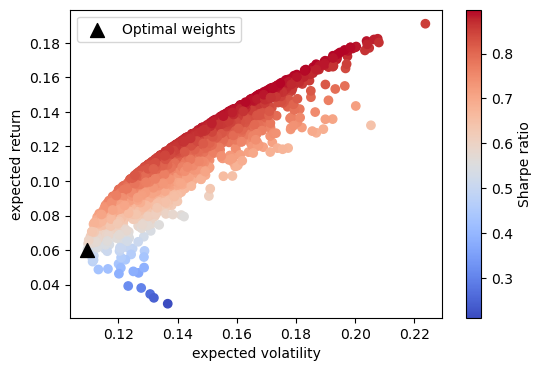

In [63]:
constraints = ({'type': 'eq',
                'fun': lambda x: np.sum(x) -1},
                )

results = scipy.optimize.minimize(
    fun=port_volatility,
    x0=np.array([1 / nAssets] * nAssets),
    method='SLSQP',
    bounds=[(0, 1) for _ in range(nAssets)],
    constraints=constraints,
)

opt_weights = results['x']
opt_port_return = port_return(opt_weights)
opt_port_volatility = port_volatility(opt_weights)
opt_sharpe_ratio = opt_port_return / opt_port_volatility

print("Minimization of Portfolio Variance")
print(f"Optimal weights: {opt_weights}")
print(f"Portfolio return with optimal weights: {opt_port_return}")
print(f"Portfolio volatility with optimal weights: {opt_port_volatility}")
print(f"Sharpe ratio with optimal weights: {opt_sharpe_ratio}")

prets = []
pvols = []
for p in range (2500):
    weights = np.random.random(nAssets)
    weights /= np.sum(weights)
    prets.append(port_return(weights))
    pvols.append(port_volatility(weights))
prets = np.array(prets)
pvols = np.array(pvols)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
sc = ax.scatter(
    pvols,
    prets,
    c=prets / pvols,
    marker='o',
    cmap='coolwarm' 
)
ax.scatter(np.array(opt_port_volatility), np.array(opt_port_return), color='black', marker='^', s=100, label='Optimal weights')
ax.set_xlabel('expected volatility')
ax.set_ylabel('expected return')
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Sharpe ratio')
ax.legend()
plt.show()